In [19]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import scipy as sp
import curveball # Note; run in separate environment (curveball) with scipy < 1.10
import time
import scipy.stats as stats
from pathlib import Path




# Load cultivation data
- This dataframe is created in 1C
- These OD values are corrected

In [20]:
repo_folder = Path("../..")
folder = repo_folder / 'data/1_growth_phenotyping'
figure_folder = repo_folder / "Figures" / "1_growth_phenotyping"

df = pd.read_csv(folder / "od_all_species_long.csv", index_col=0)

In [21]:
binary_growth = pd.read_csv(folder/'growth_no_growth.csv', index_col = 0)

In [22]:
binary_growth_dict = binary_growth.to_dict()

## Load background data


In [23]:
df.replace({'Carbon source': 'No cs'}, 'No CS', inplace=True)

In [24]:
species = ['At', 'Ct', 'Ml', 'Oa']
cs_list = sorted(df['Carbon source'].unique(), key=lambda x: (x == "No CS", x))
df['Time'] = df['Hours'] # Needed for curveball

In [25]:
cs_list

['Acetate',
 'Adenosine',
 'Alanine',
 'Arabinose',
 'Arginine',
 'Aspartate',
 'Citrate',
 'Cysteine',
 'Formate',
 'Fumarate',
 'Glucose',
 'Glutamate',
 'Glutamine',
 'Glutarate',
 'Glycerol',
 'Glycine',
 'Histidine',
 'Inosine',
 'Isoleucine',
 'Lactate',
 'Leucine',
 'Malate',
 'Mannitol',
 'Mannose',
 'Myo-inositol',
 'Orotate',
 'Phenylalanine',
 'Proline',
 'Pyruvate',
 'Ribose',
 'Sucrose',
 'Uridine',
 'Xylose',
 'No CS']

# Fit growth curves
For this I use the curveball package https://curveball.yoavram.com/


In [26]:
def store_results(s, cs, model_fits = None, idx = None):
    res = {}
    # res['folder'] = os.path.dirname(filepath)
    # res['filename'] = os.path.splitext(os.path.basename(fn))[0]
    res['Species'] = s
    res['Carbon source'] = cs
    
   
    curr_idx = idx
    if model_fits:
        mu = np.nan
        while np.isnan(mu):
            print(s, cs, idx)
            fit = model_fits[idx]
            res['model'] = fit.model.name
            res['RSS'] = fit.chisqr
            res['RMSD'] = np.sqrt(res['RSS'] / fit.ndata)
            # res['NRMSD'] = res['RMSD'] / (strain_df.OD.max() - strain_df.OD.min())
            # res['CV(RMSD)'] = res['RMSD'] / (strain_df.OD.mean())
            res['bic'] = fit.bic
            res['aic'] = fit.aic
            res['weighted_bic'] = fit.weighted_bic
            res['weighted_aic'] = fit.weighted_aic
            params = fit.params
            res['y0'] = params['y0'].value
            res['K'] = params['K'].value
            res['r'] = params['r'].value
            res['nu'] = params['nu'].value if 'nu' in params else 1
            res['q0'] = params['q0'].value if 'q0' in params else 0
            res['v'] = params['v'].value if 'v' in params else 0
            res['has_lag'] = curveball.models.has_lag(model_fits)
            res['has_nu'] = curveball.models.has_nu(model_fits)
            res['max_growth_rate'] = curveball.models.find_max_growth(fit)[-1]
            res['min_doubling_time'] = curveball.models.find_min_doubling_time(fit)
            res['lag'] = curveball.models.find_lag(fit)
            mu = res['max_growth_rate']
            if idx == curr_idx:
                idx = 0
                curr_idx = np.inf
            else:
                idx += 1
        
            if idx >= len(model_fits):
                print('No growth rate found')
                break
    return res

At Acetate 68.0
At Acetate 0
At Adenosine 76.0
At Adenosine 0
At Alanine 62.0
At Alanine 0
At Arabinose 52.0
At Arabinose 0
At Arginine 51.0
At Arginine 0
At Aspartate 29.0
At Aspartate 0
At Cysteine 32.0
At Cysteine 0
At Formate 76.0
At Formate 0
At Fumarate 25.0
At Fumarate 0
At Glucose 44.0
At Glucose 0
At Glutamate 35.0
At Glutamate 0
At Glutamine 36.0
At Glutamine 0
At Glutarate 74.0
At Glutarate 0
At Glycerol 59.0
At Glycerol 0
At Histidine 45.0
At Histidine 0
At Inosine 76.0
At Inosine 0
At Lactate 37.0
At Lactate 0
At Leucine 76.0
At Leucine 0
At Malate 42.0
At Malate 0
At Mannitol 32.0
At Mannitol 0
At Mannose 40.0
At Mannose 0
At Myo-inositol 36.0
At Myo-inositol 0
At Orotate 42.0
At Orotate 0
At Proline 47.0
At Proline 0
At Pyruvate 33.0
At Pyruvate 0
At Ribose 58.0
At Ribose 0
At Sucrose 30.0
At Sucrose 0
At Uridine 76.0
At Uridine 0
At Xylose 51.0
At Xylose 0
Ct Acetate 27.0
Ct Acetate 0
Ct Alanine 76.0
Ct Alanine 0
Ct Aspartate 19.0
Ct Aspartate 0
Ct Citrate 73.0
Ct Citra

/Users/snorre/miniconda3/envs/curveball/lib/python3.11/site-packages/curveball/models.py:640: UserWarning: All values are below K/e
  warn("All values are below K/e")


Ml Glutarate 0
Ml Glycerol 56.0
Ml Glycerol 0
Ml Glycine 72.0
Ml Glycine 0
Ml Histidine 49.0
Ml Histidine 0
Ml Inosine 59.0
Ml Inosine 0
Ml Isoleucine 73.0
Ml Isoleucine 0
Ml Isoleucine 0
Ml Isoleucine 1
Ml Lactate 72.0


/Users/snorre/miniconda3/envs/curveball/lib/python3.11/site-packages/curveball/models.py:640: UserWarning: All values are below K/e
  warn("All values are below K/e")


Ml Lactate 0
Ml Leucine 73.0
Ml Leucine 0
Ml Malate 72.0
Ml Malate 0
Ml Mannitol 52.0
Ml Mannitol 0
Ml Mannose 51.0
Ml Mannose 0
Ml Myo-inositol 73.0
Ml Myo-inositol 0
Ml Phenylalanine 73.0
Ml Phenylalanine 0
Ml Proline 73.0
Ml Proline 0
Ml Pyruvate 90.0
Ml Pyruvate 0
Ml Ribose 73.0
Ml Ribose 0
Ml Sucrose 51.0
Ml Sucrose 0
Ml Uridine 73.0
Ml Uridine 0
Ml Xylose 73.0
Ml Xylose 0
Oa Acetate 43.0
Oa Acetate 0
Oa Alanine 43.0
Oa Alanine 0
Oa Arabinose 66.0
Oa Arabinose 0
Oa Arginine 60.0
Oa Arginine 0
Oa Aspartate 53.0
Oa Aspartate 0
Oa Citrate 86.0
Oa Citrate 0
Oa Cysteine 59.0
Oa Cysteine 0
Oa Fumarate 24.0
Oa Fumarate 0
Oa Glucose 40.0
Oa Glucose 0
Oa Glutamate 43.0
Oa Glutamate 0
Oa Glutamine 75.0
Oa Glutamine 0
Oa Glutarate 50.0
Oa Glutarate 0
Oa Glycine 42.0
Oa Glycine 0
Oa Histidine 43.0
Oa Histidine 0
Oa Inosine 76.0
Oa Inosine 0
Oa Inosine 0
Oa Inosine 1
Oa Inosine 2
Oa Isoleucine 76.0


/Users/snorre/miniconda3/envs/curveball/lib/python3.11/site-packages/curveball/models.py:640: UserWarning: All values are below K/e
  warn("All values are below K/e")


Oa Isoleucine 0
Oa Lactate 35.0
Oa Lactate 0
Oa Leucine 76.0
Oa Leucine 0
Oa Malate 24.0
Oa Malate 0
Oa Mannitol 75.0
Oa Mannitol 0
Oa Mannose 53.0
Oa Mannose 0
Oa Myo-inositol 45.0
Oa Myo-inositol 0
Oa Proline 53.0
Oa Proline 0
Oa Pyruvate 39.0
Oa Pyruvate 0
Oa Ribose 66.0
Oa Ribose 0
Oa Sucrose 36.0
Oa Sucrose 0
Oa Xylose 47.0
Oa Xylose 0


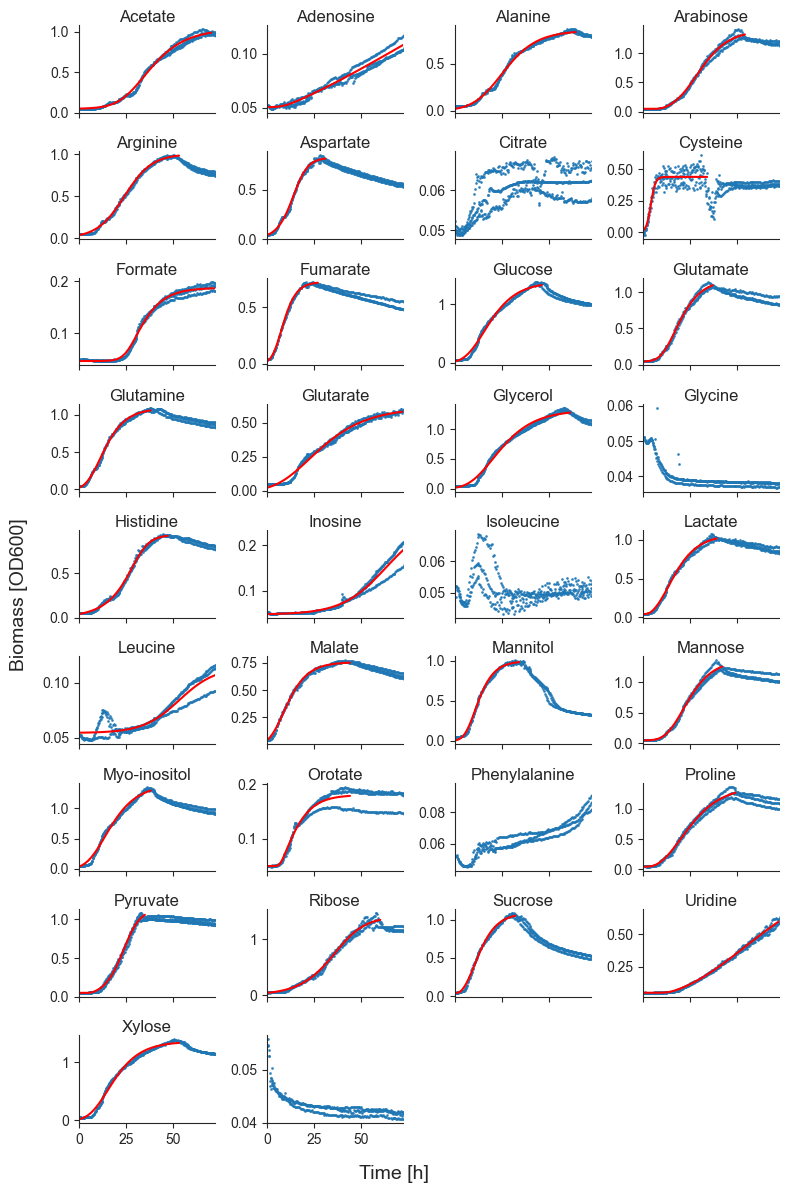

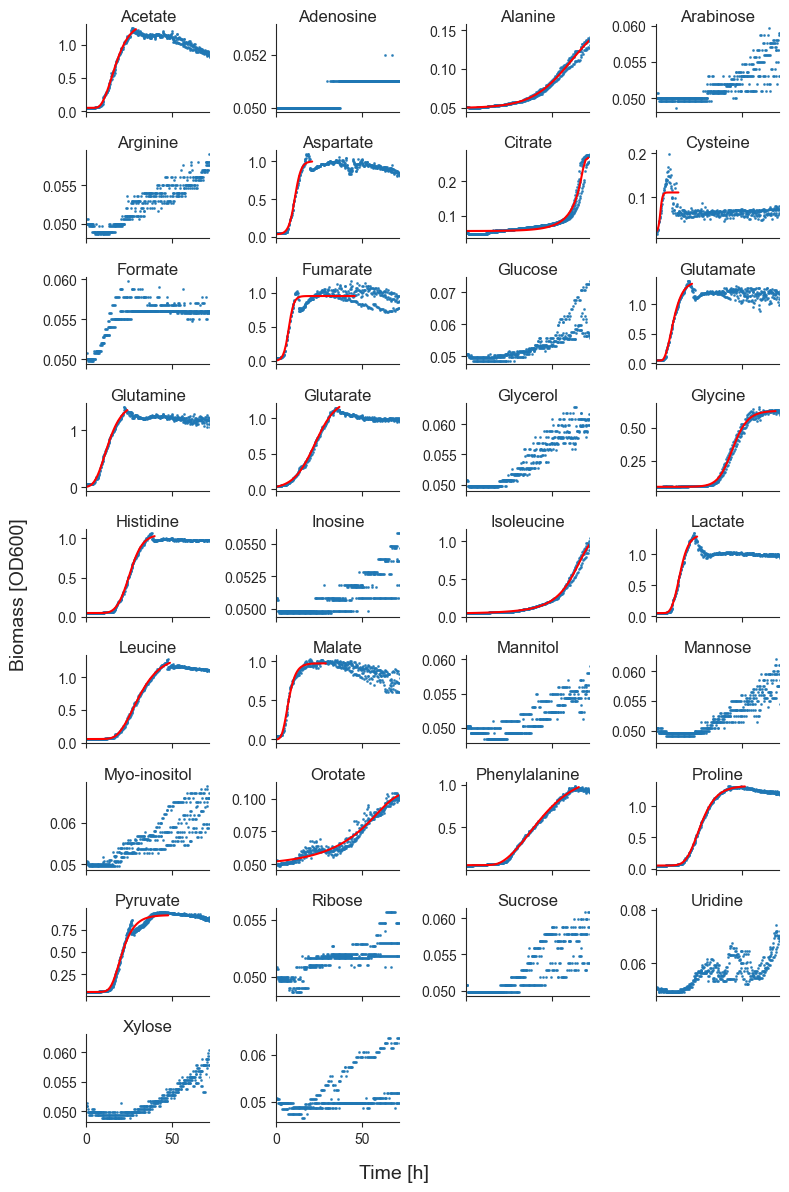

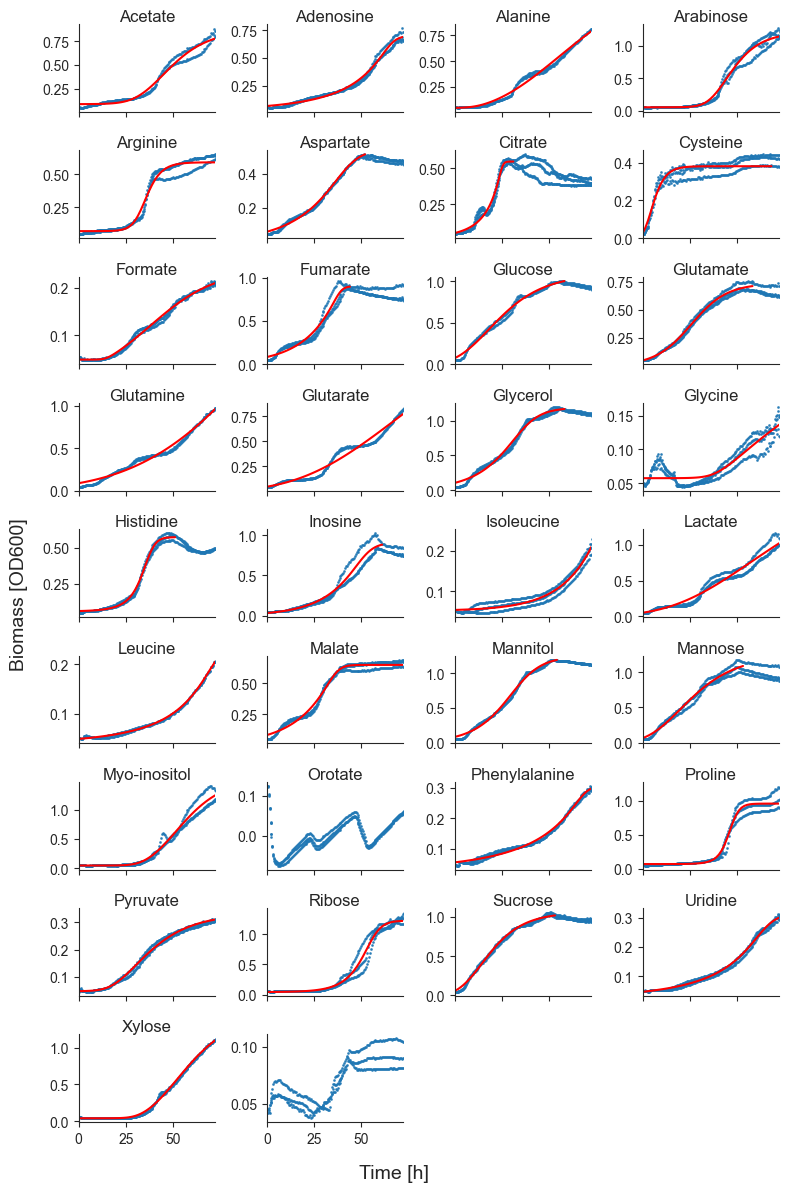

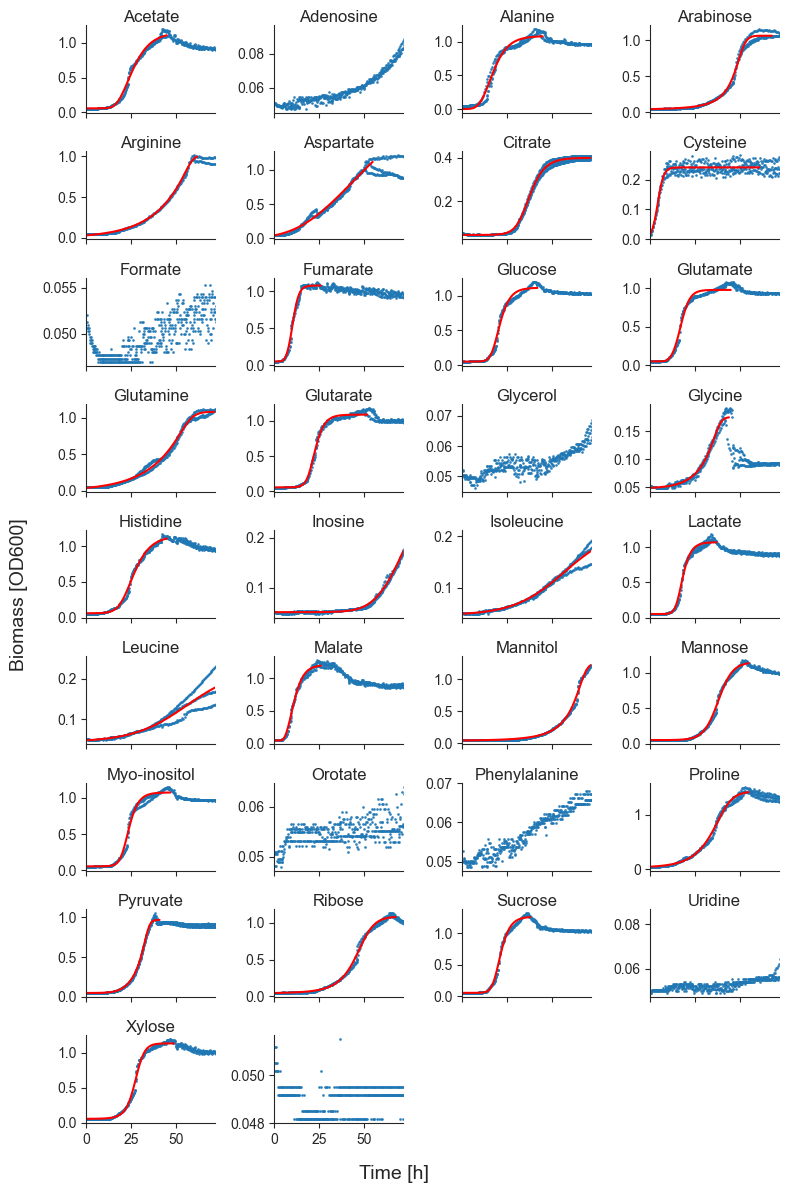

In [27]:
time_buffer = 2
min_max_time = 10
list_of_dicts = []
# models = [curveball.baranyi_roberts_model.BaranyiRoberts, 
#           curveball.baranyi_roberts_model.Richards]
for s in species:
    fig, axes = plt.subplots(9, 4, sharex = True, figsize = (8, 12))
    # for i in range(8):
    #     axes[i, 0].set_ylabel('Biomass [OD600]')
        
    # for i in range(4):
    #     axes[-1, i].set_xlabel('Time [h]')
        
    sns.despine(fig)
    axes = axes.flatten()
    for i, cs in enumerate(cs_list):
        # print(s, cs)
        ax = axes[i]
        idx = (df.Species == s) & (df['Carbon source']==cs)
        dfi = df.loc[idx,:]
        ax.scatter(dfi['Time'], dfi['OD'], s = 1, alpha = 0.8)
        if cs == 'No CS':
            continue
        if binary_growth_dict[s][cs]:
            peak_time = np.ceil(dfi.loc[dfi.Time>min_max_time, ['Time','OD']].groupby('Time').mean().idxmax().values[0])
            # max_time = np.ceil(dfi['Time'].max())
            print(s, cs, peak_time)
            
            # Calculate average growth rate until peak_time
            data_until_peak = dfi.loc[dfi['Time'] <= peak_time, :].copy()
            avg_data_peak = data_until_peak[['Time', 'OD']].groupby('Time').mean().reset_index()
            avg_data_peak = avg_data_peak[avg_data_peak['OD'] > 0]
            avg_data_peak['ln_OD'] = np.log(avg_data_peak['OD'])
            
            slope_to_peak, intercept_peak, r_peak, p_peak, std_err_peak = stats.linregress(
                avg_data_peak['Time'], avg_data_peak['ln_OD']
            )

            # Fit
            dfit = dfi.loc[dfi['Time']<=peak_time+time_buffer,:]
            model_fit = curveball.models.fit_model(dfit, PRINT=False, PLOT = False, models = None)
            # print(curveball.models.find_max_growth(model_fits[0])[-1])
            # Use baranyi roberts for growth rate
            # model_idx = np.where([x.model.name=='Model(BaranyiRoberts)' for x in model_fit])[0][0]
            model_idx = 0
            t = np.linspace(0, model_fit[model_idx].userkws['t'].max())
            y_pred = model_fit[model_idx].model.eval(t=t, params=model_fit[model_idx].params)
            
            ax.plot(t,y_pred, c = 'r')
            # Store results 
            dic = store_results(s, cs, model_fit, model_idx)
            dic['Binary growth evaluation'] = 1
            dic['avg_growth_rate_to_peak'] = slope_to_peak  # NEW: Add this field
            dic['r2_growth_to_peak'] = r_peak**2  # NEW: R² value for growth rate fit
        else:
            dic = store_results(s, cs, None)
            dic['Binary growth evaluation'] = 0
            dic['avg_growth_rate_to_peak'] = np.nan  # NEW: Add NaN for no growth
            dic['r2_growth_to_peak'] = np.nan  # NEW
    
        mean_od = dfi[['Time','OD']].groupby('Time').mean()
        dic['Yield'] = (mean_od.max()-mean_od.iloc[0]).values[0]
        
        list_of_dicts.append(dic)    
        ax.set_title(cs, pad = -50)
        ax.set_xlim(0, 72)
    for i in range(i+1, 9*4):
        axes[i].axis('off')
    fig.supylabel('Biomass [OD600]', size = 14)
    fig.supxlabel('Time [h]', size = 14)
    plt.tight_layout()
    plt.savefig(figure_folder / f'fitted_growth_curves_{s}.pdf')



In [28]:
res_df = pd.DataFrame(list_of_dicts)

In [29]:
res_df.to_csv(folder / 'fitted_growth_parameters.csv')

In [30]:
res_df

,Species,Carbon source,model,RSS,RMSD,bic,aic,weighted_bic,weighted_aic,y0,...,v,has_lag,has_nu,max_growth_rate,min_doubling_time,lag,Binary growth evaluation,avg_growth_rate_to_peak,r2_growth_to_peak,Yield
0,At,Acetate,Model(BaranyiRoberts),0.322344,0.027704,-2976.162050,-3000.403578,0.945639,0.992433,0.051560,...,0.167623,True,True,0.095601,7.355898,20.276668,1,0.052950,0.932601,0.943733
1,At,Adenosine,Model(LogisticLag2),0.006108,0.003672,-5049.413284,-5069.992745,0.835421,0.537886,0.050400,...,0.405452,True,False,0.013572,58.409173,14.478764,1,0.011653,0.992079,0.061100
2,At,Alanine,Model(Richards),0.179883,0.021644,-2919.976054,-2935.778625,0.949095,0.665241,0.019609,...,0.000000,False,True,0.133138,4.355411,10.193895,1,0.050233,0.852186,0.813300
3,At,Arabinose,Model(BaranyiRoberts),0.502418,0.039379,-2061.293329,-2083.977790,0.920329,0.996867,0.050640,...,1.019883,True,True,0.144967,4.485333,16.196443,1,0.077640,0.931409,1.265300
4,At,Arginine,Model(Logistic),0.081694,0.016028,-2611.565656,-2622.851810,0.411548,0.006139,0.034343,...,0.000000,False,False,0.119682,5.303915,10.650526,1,0.065648,0.874026,0.924733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,Oa,Pyruvate,Model(BaranyiRoberts),0.089217,0.015549,-3037.373960,-3060.838739,0.985932,0.997985,0.047407,...,0.310494,True,True,0.156408,4.467260,25.623200,1,0.094768,0.922242,0.970033
128,Oa,Ribose,Model(BaranyiRoberts),0.271740,0.025808,-2948.116771,-2972.184374,0.591154,0.914852,0.046243,...,0.092135,True,True,0.103032,6.805417,35.932256,1,0.061129,0.954169,1.065000
129,Oa,Sucrose,Model(BaranyiRoberts),0.321803,0.037569,-1463.825027,-1484.401101,0.999714,0.999948,0.050782,...,0.595485,True,True,0.356051,1.977255,16.273629,1,0.125627,0.910689,1.257667
130,Oa,Uridine,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0.016667


In [31]:
# Example: Calculate average growth rate until peak_time for a specific case
# This shows you how to extract it from the raw data

from scipy import stats

# Select a specific species and carbon source to demonstrate
s_example = 'At'
cs_example = 'Acetate'

idx = (df.Species == s_example) & (df['Carbon source'] == cs_example)
dfi = df.loc[idx, :]

# Calculate peak_time (same logic as in your loop)
min_max_time = 10
peak_time = np.ceil(dfi.loc[dfi.Time > min_max_time, ['Time', 'OD']].groupby('Time').mean().idxmax().values[0])

# Filter data until peak_time
data_until_peak = dfi.loc[dfi['Time'] <= peak_time, :].copy()

# Calculate average OD per timepoint
avg_data = data_until_peak[['Time', 'OD']].groupby('Time').mean().reset_index()

# Filter out zero or negative OD values
avg_data = avg_data[avg_data['OD'] > 0]

# Calculate growth rate as slope of ln(OD) vs Time
avg_data['ln_OD'] = np.log(avg_data['OD'])

# Linear regression of ln(OD) vs Time
slope, intercept, r_value, p_value, std_err = stats.linregress(avg_data['Time'], avg_data['ln_OD'])

print(f"Species: {s_example}, Carbon source: {cs_example}")
print(f"Peak time: {peak_time} hours")
print(f"Average growth rate until peak: {slope:.4f} hr⁻¹")
print(f"R²: {r_value**2:.4f}")
print(f"Doubling time: {np.log(2)/slope:.2f} hours")

Species: At, Carbon source: Acetate
Peak time: 68.0 hours
Average growth rate until peak: 0.0529 hr⁻¹
R²: 0.9326
Doubling time: 13.09 hours
